In [3]:
# os
import os, sys, random

# visualization
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# ml
import numpy as np
import torchvision as tv
import torch
from PIL import Image

# data aug
import copy
import os
import random
import shutil
from collections import defaultdict
from urllib.request import urlretrieve

# helpers
import dataloader as dl
from pathlib import Path
import helpers as help

sys.path.append('../streaming_base')
#from streaming_base.processing.processing import beamform_2d
from streaming_base.utils.utils import get_ant_pos_2d, plot_2d_polar_heatmap, plot_2d_heatmap
from utils.utility import read_radar_params

%load_ext autoreload
%autoreload 2

In [4]:
# Global Vars
_DEBUG = True
ROOT_DIR = "../../data/"
OUTPUT_DIR = "../submission/"

In [5]:
print("Is CUDA available: ", torch.cuda.is_available())
print("CUDA device count: ", torch.cuda.device_count())
print("Current CUDA device: ", torch.cuda.current_device())
print("CUDA device name: ", torch.cuda.get_device_name(torch.cuda.current_device()))
print("PyTorch version: ", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Is CUDA available:  True
CUDA device count:  1
Current CUDA device:  0
CUDA device name:  NVIDIA GeForce RTX 3080 Laptop GPU
PyTorch version:  2.9.1+cu128
Using device:  cuda


In [6]:
# Helper functions
def load_image(infilename):
    data = mpimg.imread(infilename)
    return data


def img_float_to_uint8(img):
    rimg = img - np.min(img)
    rimg = (rimg / np.max(rimg) * 255).round().astype(np.uint8)
    return rimg


# Concatenate an image and its groundtruth
def concatenate_images(img, gt_img):
    nChannels = len(gt_img.shape)
    w = gt_img.shape[0]
    h = gt_img.shape[1]
    if nChannels == 3:
        cimg = np.concatenate((img, gt_img), axis=1)
    else:
        gt_img_3c = np.zeros((w, h, 3), dtype=np.uint8)
        gt_img8 = img_float_to_uint8(gt_img)
        gt_img_3c[:, :, 0] = gt_img8
        gt_img_3c[:, :, 1] = gt_img8
        gt_img_3c[:, :, 2] = gt_img8
        img8 = img_float_to_uint8(img)
        cimg = np.concatenate((img8, gt_img_3c), axis=1)
    return cimg


def img_crop(im, w, h):
    list_patches = []
    imgwidth = im.shape[0]
    imgheight = im.shape[1]
    is_2d = len(im.shape) < 3
    for i in range(0, imgheight, h):
        for j in range(0, imgwidth, w):
            if is_2d:
                im_patch = im[j : j + w, i : i + h]
            else:
                im_patch = im[j : j + w, i : i + h, :]
            list_patches.append(im_patch)
    return list_patches

In [7]:
home_dir = "D:/GitHub/COM-304-Rat-Detection"

capture_data_dir = "data/pipe-data/20-4-26/pipe-raw"

filename = "highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128_Raw_0"

json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config_highres.lua' 

In [8]:
args, chirp_dict = dl.read_lua_config(home_dir, config_lua_script)


In [9]:
raw_rat_capture_data_dir = r"data/rat-data/20-4-26/rat-raw"

jerry_name = "highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128"
mike_name = "highres_rat_setup-michael_take-1_fs-2420_slp-62-474_N-128"

jerry_raw, jerry_fft = dl.load_radar_capture(jerry_name, raw_rat_capture_data_dir, home_dir, json_filename, args)
mike_raw, mike_fft = dl.load_radar_capture(mike_name, raw_rat_capture_data_dir, home_dir, json_filename, args)

In [10]:
raw_pipe_capture_data_dir = r"data/rat-data/20-4-26/pipe-raw"
raw_pipe_capture_data_dir2 = r"data/rat-data/27-4-26/empty-pipe"

pipe1_name = ("highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128")
pipe2_name = ("highres_rat_setup-pipe_take-2_fs-2420_slp-62-474_N-128")
pipe3_name = ("highres_rat_setup-pipe_take-3_fs-2420_slp-62-474_N-128")
pipe4_name = ("highres_rat_setup-pipe_take-4_fs-2420_slp-62-474_N-128")
pipe5_name = ("highres_rat_setup-pipe_take-5_fs-2420_slp-62-474_N-128")


pipe1_raw, pipe1_fft = dl.load_radar_capture(pipe1_name, raw_pipe_capture_data_dir, home_dir, json_filename, args)
pipe2_raw, pipe2_fft = dl.load_radar_capture(pipe2_name, raw_pipe_capture_data_dir, home_dir, json_filename, args)
pipe3_raw, pipe3_fft = dl.load_radar_capture(pipe3_name, raw_pipe_capture_data_dir, home_dir, json_filename, args)
pipe4_raw, pipe4_fft = dl.load_radar_capture(pipe4_name, raw_pipe_capture_data_dir, home_dir, json_filename, args)
pipe5_raw, pipe5_fft = dl.load_radar_capture(pipe5_name, raw_pipe_capture_data_dir, home_dir, json_filename, args)

In [11]:
new_pipe_raw = [None] * 11
new_pipe_fft = [None] * 11

for i in range(10):#
    new_pipe_raw[i+1], new_pipe_fft[i+1] = dl.load_radar_capture(f"pipe_take{i+1}", raw_pipe_capture_data_dir2, home_dir, json_filename, args)


In [12]:
import re

folder = Path(r"../data/rat-data/27-4-26/empty-pipe")

pattern = re.compile(r"^(.*)_Raw_\d+\.bin$")


empty_pipe_names = []
empty_pipe_raw = []
empty_pipe_fft = []

for file in folder.glob("*_Raw_*.bin"):
    match = pattern.match(file.name)
    if match:
        empty_pipe_names.append(match.group(1))

for name in empty_pipe_names:
    raw, fft = dl.load_radar_capture(name, raw_pipe_capture_data_dir2, home_dir, json_filename, args)
    empty_pipe_raw.append(raw)
    empty_pipe_fft.append(fft)

print(len(empty_pipe_names))

10


In [13]:
full_pipe_capture_data_dir = r"data/rat-data/20-4-26/full-pipe"

rubber_name  = "highres_rat_setup-piped-eraser-antenna-aligned_take-1_fs-2420_slp-62-474_N-128"

jerry_pipe_name1 = "highres_rat_setup-piped-jerry_take-1_fs-2420_slp-62-474_N-128"
jerry_pipe_name2 = "highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128"
jerry_pipe_aligned_name = "highres_rat_setup-piped-jerry-antenna-aligned_take-3_fs-2420_slp-62-474_N-128" 

rubber_raw, rubber_fft = dl.load_radar_capture(rubber_name, full_pipe_capture_data_dir, home_dir, json_filename, args)
jerry_pipe_raw1, jerry_pipe_fft1 = dl.load_radar_capture(jerry_pipe_name1, full_pipe_capture_data_dir, home_dir, json_filename, args)
jerry_pipe_raw2, jerry_pipe_fft2 = dl.load_radar_capture(jerry_pipe_name2, full_pipe_capture_data_dir, home_dir, json_filename, args)
jerry_pipe_aligned_raw, jerry_pipe_aligned_fft = dl.load_radar_capture(jerry_pipe_aligned_name, full_pipe_capture_data_dir, home_dir, json_filename, args)  


In [14]:
from pathlib import Path
import re

new_full_dir = r"data/rat-data/27-4-26/full-pipe"
folder = Path(r"../data/rat-data/27-4-26/full-pipe")

pattern = re.compile(r"^(.*)_Raw_\d+\.bin$")


full_pipe_names = []
full_pipe_raw = []
full_pipe_fft = []

for file in folder.glob("*_Raw_*.bin"):
    match = pattern.match(file.name)
    if match:
        full_pipe_names.append(match.group(1))

for name in full_pipe_names:
    raw, fft = dl.load_radar_capture(name, new_full_dir, home_dir, json_filename, args)
    full_pipe_raw.append(raw)
    full_pipe_fft.append(fft)

print(full_pipe_names)
print(len(full_pipe_names))
print(len(full_pipe_raw))
print(len(full_pipe_fft))

['pipe_iron_jerry_left_take10', 'pipe_iron_jerry_left_take1', 'pipe_iron_jerry_left_take2', 'pipe_iron_jerry_left_take3', 'pipe_iron_jerry_left_take4', 'pipe_iron_jerry_left_take5', 'pipe_iron_jerry_left_take6', 'pipe_iron_jerry_left_take7', 'pipe_iron_jerry_left_take8', 'pipe_iron_jerry_left_take9', 'pipe_iron_jerry_mid_idle_take10', 'pipe_iron_jerry_mid_idle_take1', 'pipe_iron_jerry_mid_idle_take2', 'pipe_iron_jerry_mid_idle_take3', 'pipe_iron_jerry_mid_idle_take4', 'pipe_iron_jerry_mid_idle_take5', 'pipe_iron_jerry_mid_idle_take6', 'pipe_iron_jerry_mid_idle_take7', 'pipe_iron_jerry_mid_idle_take8', 'pipe_iron_jerry_mid_idle_take9', 'pipe_iron_jerry_quart_left_idle_take10', 'pipe_iron_jerry_quart_left_idle_take1', 'pipe_iron_jerry_quart_left_idle_take2', 'pipe_iron_jerry_quart_left_idle_take3', 'pipe_iron_jerry_quart_left_idle_take4', 'pipe_iron_jerry_quart_left_idle_take5', 'pipe_iron_jerry_quart_left_idle_take6', 'pipe_iron_jerry_quart_left_idle_take7', 'pipe_iron_jerry_quart_left_

In [15]:
ffts = [jerry_fft, mike_fft, pipe1_fft, pipe2_fft, pipe3_fft, pipe4_fft, pipe5_fft, rubber_fft, jerry_pipe_fft1, jerry_pipe_fft2, jerry_pipe_aligned_fft]
fft_names = ["jerry", "michael", "pipe1", "pipe2", "pipe3", "pipe4", "pipe5", "rubber_eraser", "jerry_pipe1", "jerry_pipe2", "jerry_pipe_aligned"]

all_names = full_pipe_names + empty_pipe_names + fft_names
all_ffts = full_pipe_fft + empty_pipe_fft + ffts

print("FFT shapes:")
for i, fft in enumerate(all_ffts):
    print(f"{all_names[i]}: {fft.shape}")

FFT shapes:
pipe_iron_jerry_left_take10: (20, 3, 4, 128)
pipe_iron_jerry_left_take1: (20, 3, 4, 128)
pipe_iron_jerry_left_take2: (20, 3, 4, 128)
pipe_iron_jerry_left_take3: (20, 3, 4, 128)
pipe_iron_jerry_left_take4: (20, 3, 4, 128)
pipe_iron_jerry_left_take5: (20, 3, 4, 128)
pipe_iron_jerry_left_take6: (20, 3, 4, 128)
pipe_iron_jerry_left_take7: (20, 3, 4, 128)
pipe_iron_jerry_left_take8: (20, 3, 4, 128)
pipe_iron_jerry_left_take9: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take10: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take1: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take2: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take3: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take4: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take5: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take6: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take7: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take8: (20, 3, 4, 128)
pipe_iron_jerry_mid_idle_take9: (20, 3, 4, 128)
pipe_iron_jerry_quart_left_idle_take10: (20, 3, 4, 128)
pipe_iron_

# ignore michael, jerry (not in pipe) and pipe5 (see below) for now

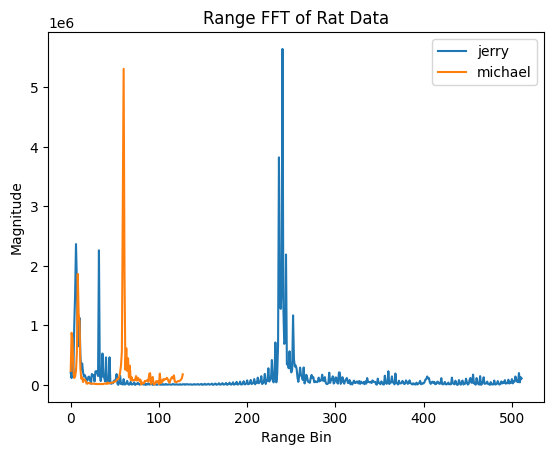

In [16]:
plt.plot(abs(np.squeeze(np.sum(jerry_fft, axis=(0,2,1)))))
plt.plot(abs(np.squeeze(np.sum(mike_fft,axis=(0,2,1)))))
plt.legend(['jerry', 'michael'])
plt.xlabel('Range Bin')
plt.ylabel('Magnitude')
plt.title('Range FFT of Rat Data')
plt.show()

Plotting FFTs for all captures...
['pipe_iron_jerry_left_take10', 'pipe_iron_jerry_left_take1', 'pipe_iron_jerry_left_take2', 'pipe_iron_jerry_left_take3', 'pipe_iron_jerry_left_take4', 'pipe_iron_jerry_left_take5', 'pipe_iron_jerry_left_take6', 'pipe_iron_jerry_left_take7', 'pipe_iron_jerry_left_take8', 'pipe_iron_jerry_left_take9', 'pipe_iron_jerry_mid_idle_take10', 'pipe_iron_jerry_mid_idle_take1', 'pipe_iron_jerry_mid_idle_take2', 'pipe_iron_jerry_mid_idle_take3', 'pipe_iron_jerry_mid_idle_take4', 'pipe_iron_jerry_mid_idle_take5', 'pipe_iron_jerry_mid_idle_take6', 'pipe_iron_jerry_mid_idle_take7', 'pipe_iron_jerry_mid_idle_take8', 'pipe_iron_jerry_mid_idle_take9', 'pipe_iron_jerry_quart_left_idle_take10', 'pipe_iron_jerry_quart_left_idle_take1', 'pipe_iron_jerry_quart_left_idle_take2', 'pipe_iron_jerry_quart_left_idle_take3', 'pipe_iron_jerry_quart_left_idle_take4', 'pipe_iron_jerry_quart_left_idle_take5', 'pipe_iron_jerry_quart_left_idle_take6', 'pipe_iron_jerry_quart_left_idle_ta

C:\Users\janva\AppData\Local\Temp\ipykernel_3228\729336978.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


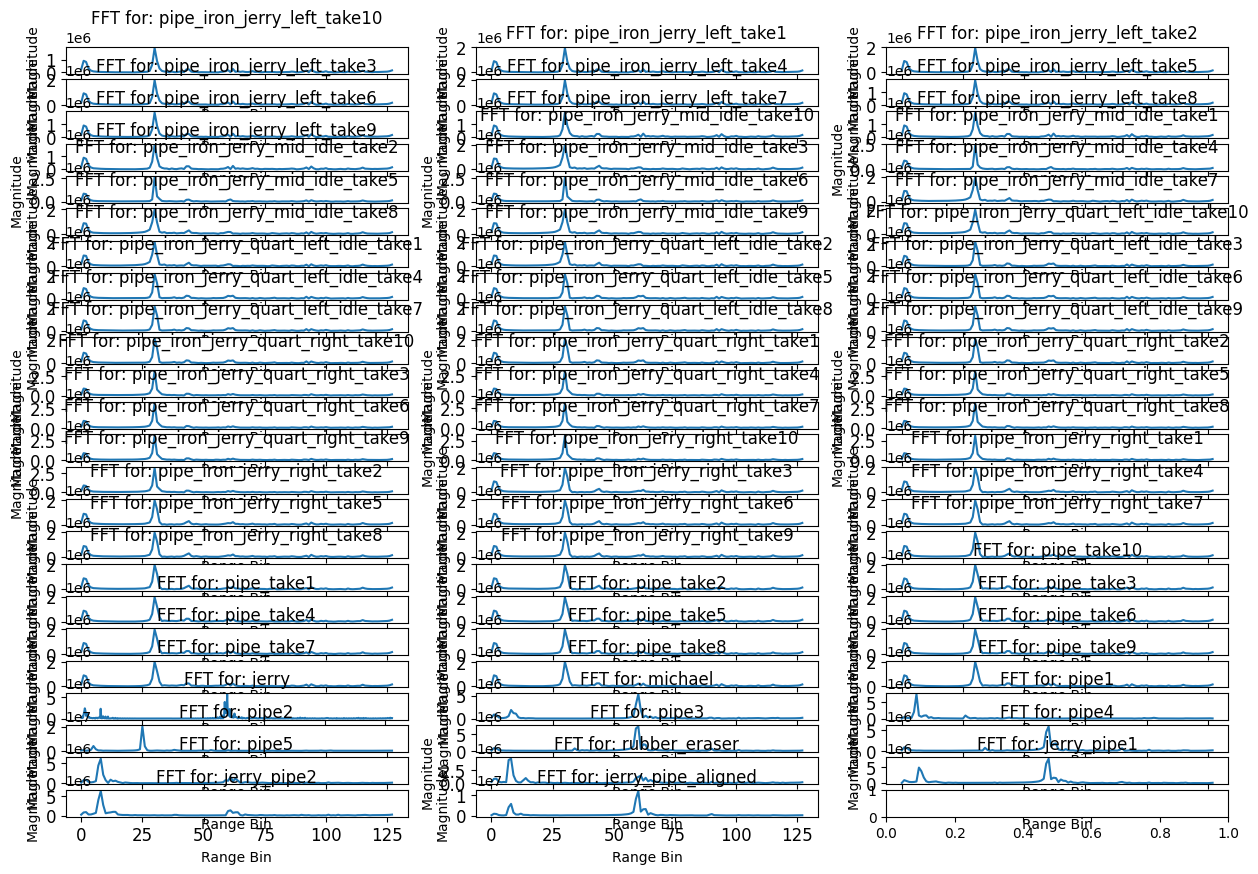

In [17]:
fig, axs = plt.subplots(len(all_ffts) // 3 + (len(all_ffts) % 3 > 0), 3, figsize=(15, 10))
print("Plotting FFTs for all captures...")
print(all_names)

for i, fft in enumerate(all_ffts):
    ax = axs[i // 3, i % 3]  # convert index → grid position
    signal = abs(np.squeeze(np.sum(fft, axis=(0,2,1))))
    ax.plot(signal)
    ax.set_title(f"FFT for: {all_names[i]}")
    ax.set_xlabel('Range Bin')
    ax.set_ylabel('Magnitude')
    ax.fontsize = 8
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

In [22]:
def to_virtual_ant(fft):
    # fft shape: (num_chirps, num_rx, num_tx, num_range_bins)
    # sum across tx and rx to get virtual antenna signal
    chirps, num_rx, num_tx, num_range_bins = fft.shape
    fft = fft.reshape(chirps, num_rx * num_tx, num_range_bins) 
    return fft

# apply to all ffts
virtual_ant_signals = [to_virtual_ant(fft) for fft in all_ffts]
for i, vas in enumerate(virtual_ant_signals):
    print(f"Virtual antenna signal shape for {all_names[i]}: {vas.shape}")

# form dict of virt signals with names
virtual_ant_dict = {all_names[i]: virtual_ant_signals[i] for i in range(len(all_names))}
print("Virtual antenna signals stored in dict with keys: ", virtual_ant_dict.keys())

Virtual antenna signal shape for pipe_iron_jerry_left_take10: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take1: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take2: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take3: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take4: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take5: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take6: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take7: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take8: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_left_take9: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_mid_idle_take10: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_mid_idle_take1: (20, 12, 128)
Virtual antenna signal shape for pipe_iron_jerry_mid_idle_take2: (20, 12, 128)
Virtual ant

In [23]:
# prep for beamform
num_rx = args[0] 
num_tx = args[1]
num_chirps = args[2]
num_loops = args[3]

print(args)
num_virtual_ant = num_rx * num_tx
print("Number of virtual antennas: ", num_virtual_ant)

samples_per_frame = num_virtual_ant * num_chirps * num_loops  # num_virtual_ant * samples_per_chirp * chirp_loop
print("Samples per frame: ", samples_per_frame)

num_frames = virtual_ant_dict[fft_names[10]].shape[0] 
print("Number of frames in each capture: ", num_frames)

names_to_drop = ["michael", "jerry", "pipe1"]

for name in names_to_drop:
    if name in virtual_ant_dict:
        del virtual_ant_dict[name]
        print(f"Dropped {name} from virtual antenna dict.")
    else:
        print(f"{name} not found in virtual antenna dict, cannot drop.")

print(len(virtual_ant_dict))


#class = ['rat': 1, 'not_rat': 0] 
# add class to virtual_ant_dict
labels = {
    "pipe1": 0,
    "pipe2": 0,
    "pipe3": 0,
    "pipe4": 0,
    "pipe5": 0,
    "rubber_eraser": 0,

    "jerry_pipe1": 1,
    "jerry_pipe2": 1,
    "jerry_pipe_aligned": 1
}
print("Labels for CNN: ", labels)

labeled_data = {}
for name, data in virtual_ant_dict.items():
    labeled_data[name] = {
        "data": data,
        "label": labels[name]
    }
print("Labeled data dict keys: ", labeled_data.keys())

[3, 4, 128, 1, '0x7', '0xF']
Number of virtual antennas:  12
Samples per frame:  1536
Number of frames in each capture:  20
Dropped michael from virtual antenna dict.
Dropped jerry from virtual antenna dict.
Dropped pipe1 from virtual antenna dict.
68
Labels for CNN:  {'pipe1': 0, 'pipe2': 0, 'pipe3': 0, 'pipe4': 0, 'pipe5': 0, 'rubber_eraser': 0, 'jerry_pipe1': 1, 'jerry_pipe2': 1, 'jerry_pipe_aligned': 1}


KeyError: 'pipe_iron_jerry_left_take10'

In [29]:
new_ml_data_dir = "data/ml"

names, raw_data, fft_data = help.load_data(new_ml_data_dir, home_dir, json_filename, args)
virtual_ant_dict = help.make_virtual_ant_dict(fft_data, names)


print("Loaded data for ML from directory: ", new_ml_data_dir)
print("Virtual antenna dict keys after loading ML data: ", virtual_ant_dict.keys())

Loaded data for ML from directory:  data/ml
Virtual antenna dict keys after loading ML data:  dict_keys(['highres_rat_setup-piped-jerry-antenna-aligned_take-3_fs-2420_slp-62-474_N-128', 'highres_rat_setup-piped-jerry_take-1_fs-2420_slp-62-474_N-128', 'highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-2_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-3_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-4_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-5_fs-2420_slp-62-474_N-128', 'jerry_no-pipe_aligned1', 'jerry_no-pipe_aligned2', 'jerry_no-pipe_aligned3', 'jerry_no-pipe_aligned4', 'jerry_no-pipe_aligned5', 'jerry_no-pipe_aligned', 'jerry_no-pipe_lhs1', 'jerry_no-pipe_lhs2', 'jerry_no-pipe_lhs3', 'jerry_no-pipe_lhs4', 'jerry_no-pipe_lhs5', 'jerry_no-pipe_rhs1', 'jerry_no-pipe_rhs2', 'jerry_no-pipe_rhs3', 'jerry_no-pipe_rhs4', 'jerry_no-pipe_rhs5', 'jerry_no-pipe_wall

In [30]:
# label data
labeled_data = {}
no_jerry_keys = ["lhs", "rhs", "left", "right"]

for name, fft in virtual_ant_dict.items():
    if (("jerry" in name.lower()) and 
        not any(key in name.lower() for key in no_jerry_keys)):
        label = 1  
    else:
        label = 0 
    labeled_data[name] = {
        "data": fft,
        "label": label
    }
    
print("Labeled data dict keys: ", labeled_data.keys())
print("Labels assigned: ")
for name in labeled_data:
    print(f"{name}: {labeled_data[name]['label']}")
    print(f"Data shape for {name}: {labeled_data[name]['data'].shape}")

Labeled data dict keys:  dict_keys(['highres_rat_setup-piped-jerry-antenna-aligned_take-3_fs-2420_slp-62-474_N-128', 'highres_rat_setup-piped-jerry_take-1_fs-2420_slp-62-474_N-128', 'highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-2_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-3_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-4_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-5_fs-2420_slp-62-474_N-128', 'jerry_no-pipe_aligned1', 'jerry_no-pipe_aligned2', 'jerry_no-pipe_aligned3', 'jerry_no-pipe_aligned4', 'jerry_no-pipe_aligned5', 'jerry_no-pipe_aligned', 'jerry_no-pipe_lhs1', 'jerry_no-pipe_lhs2', 'jerry_no-pipe_lhs3', 'jerry_no-pipe_lhs4', 'jerry_no-pipe_lhs5', 'jerry_no-pipe_rhs1', 'jerry_no-pipe_rhs2', 'jerry_no-pipe_rhs3', 'jerry_no-pipe_rhs4', 'jerry_no-pipe_rhs5', 'jerry_no-pipe_wall_aligned1', 'jerry_no-pipe_wall_aligned2', 'jerry_no-pipe_wall_aligne

In [31]:
def beamform_2d(beat_freq_data, radar_params, x_locs):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.

    Parameters
    ----------
    beat_freq_data : np.ndarray
        The beat frequency data, typically a 3D array.
    x_locs : np.ndarray
        The x-coordinates of the antennas.
    radar_params : dict
        A dictionary containing radar parameters such as sample rate, number of range samples, etc. 

    Returns
    -------
    sph_pwr : np.ndarray
        The spherical power array after beamforming, with shape (num_phi, samples_per_chirp).
    """

    # Radar parameters
    lm = radar_params["lm"]

    # Get the azimuth angles and range indices
    phi = radar_params["phi"]
    num_phi = len(phi)
    r_idxs = radar_params["range_idx"]

    # Initialize the spherical power array 
    sph_pwr = np.zeros((num_phi, r_idxs.shape[0]), dtype=np.complex64)

    # TODO: compute array for phase shifts for angles  (size: phi x x_locs)
    # this is essentially calculating d_n * cos(phi) from the README
    angles = x_locs * np.cos(phi[:, np.newaxis])

    # TODO: compute h_phi for each phase shift (size same as angles)
    # this is calculates the complex valued h_phi from the README
    #steering_vec = np.zeros(angles.shape) 
    steering_vec = np.exp(1j*2*np.pi/lm * angles)

    # Apply the phase shifts to the beat frequency data and sum over the antennas
    for r, rval in enumerate(r_idxs):
        beat = beat_freq_data[:, r]
        beamformed_signal = beat[np.newaxis, :] * steering_vec
        sph_pwr[:, r] = np.maximum(sph_pwr[:, r], np.abs(np.sum(beamformed_signal, axis=-1)))

    return sph_pwr

In [32]:
# define the azimuth angles (horizontal FOV) that we want to look at 

"""
antenna_param_data = 
radar_params, raw_data = utils.load_raw_data()

num_x_stp = num_virtual_ant  # TODO: confirm this is correct
num_z_stp = 1 

x_ant_pos, z_pos, x_ant = get_ant_pos_2d(num_x_stp, num_z_stp, num_rx)
"""

phi_s, phi_e = 60, 130 
phi_res = 2
theta_s, theta_e = 70,110 
theta_res = 2

theta = np.deg2rad(np.arange(theta_s, theta_e + theta_res, theta_res))

phi = np.deg2rad(np.arange(0, 180, 1))
width = 100 # azimuth width in degrees
adc_samples = chirp_dict['samples_per_chirp']
x_locs, _, _ = get_ant_pos_2d(num_tx * num_rx, adc_samples, num_rx)
r_idxs = np.arange(100, 140, 1) # TODO: Change to distance rather than range bins 

cfg_radar = {
        "range_idx": r_idxs,
        "phi": phi,
        "width": width,
        "n_radar": 1,
        "num_tx": chirp_dict['num_tx'],
        "num_rx": chirp_dict['num_rx'],
        "num_doppler": chirp_dict['chirp_loops'],
        "samples_per_chirp": chirp_dict['samples_per_chirp'],
        "sample_rate": chirp_dict['sample_rate'],
        "c": 3e8,
        "lm": 3e8 / 77e9,
        "slope": chirp_dict['slope'],
        "range_res": chirp_dict['range_res'],           # NOTE : I ADDED THIS -- 4/20/2026 - KERIM
}

X, y = [], []
for name in labeled_data:
    data = labeled_data[name]['data']  # (frames, ants, range)
    label = labeled_data[name]['label']

    #for frame in data:
    bf_input = np.mean(data, axis=0)  # (ants, range)

    sph_pwr = beamform_2d(
        beat_freq_data = bf_input,
        radar_params = cfg_radar,
        x_locs = x_locs[:, 0],
    )
    img = np.abs(sph_pwr)
    img = np.log1p(img)   # compress dynamic range

    # normalise
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    X.append(img)
    y.append(label)

In [33]:
X = np.array(X)       # appears ads shape (N, 180, 40)
y = np.array(y) 

X = X[:, None, :, :]   # (200, 1, 180, 40)
print("Final dataset shapes - X: ", X.shape, ", y: ", y.shape)
print(X.min(), X.max(), X.mean())

Final dataset shapes - X:  (149, 1, 180, 40) , y:  (149,)
0.0 1.0 0.5420126


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shapes - X: ", X_train.shape, ", y: ", y_train.shape)
print("Test shapes - X: ", X_test.shape, ", y: ", y_test.shape)

Train shapes - X:  (111, 1, 180, 40) , y:  (111,)
Test shapes - X:  (38, 1, 180, 40) , y:  (38,)


In [35]:
# add augmented data

def add_noise(img, sigma=0.01):
    noise = np.random.normal(0, sigma, img.shape)
    return img + noise

def random_gain(img, low=0.9, high=1.1):
    return img * np.random.uniform(low, high)

def shift_azimuth(img, max_shift=5):
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(img, shift, axis=0)

def augment_data(X, y):
    X_aug, y_aug = [], []
    for img, label in zip(X, y):
        for _ in range(6):
            out = img.copy()

            out = add_noise(out)
            out = random_gain(out)
            out = shift_azimuth(out)

            X_aug.append(out)
            y_aug.append(label)

    X_aug = np.array(X_aug)
    y_aug = np.array(y_aug)
    return X_aug, y_aug

#print("Augmented dataset shapes - X_aug: ", X_aug.shape, ", y_aug: ", y_aug.shape)
#print(X_aug.min(), X_aug.max(), X_aug.mean())

In [36]:
X_train_base = X_train.copy()
y_train_base = y_train.copy()

X_train_aug = []
y_train_aug = []

for img, label in zip(X_train_base, y_train_base):

    # keep original
    X_train_aug.append(img)
    y_train_aug.append(label)

    # add augmented versions
    for _ in range(10):
        out = img.copy()

        out = add_noise(out)
        out = random_gain(out)
        out = shift_azimuth(out)

        X_train_aug.append(out)
        y_train_aug.append(label)

X_train = np.array(X_train_aug)
y_train = np.array(y_train_aug)
print("Augmented dataset shapes - X_train: ", X_train.shape, ", y_train: ", y_train.shape)
print(X_train.min(), X_train.max(), X_train.mean())

Augmented dataset shapes - X_train:  (1221, 1, 180, 40) , y_train:  (1221,)
-0.03389819359563509 1.1245118947153063 0.5383711578524087


In [37]:
# normalise again after augmentation
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min() + 1e-8)
print("X_train shape after augmentation: ", X_train.shape)
print("X_train stats after augmentation - min: ", X_train.min(), ", max: ", X_train.max(), ", mean: ", X_train.mean())

X_train shape after augmentation:  (1221, 1, 180, 40)
X_train stats after augmentation - min:  0.0 , max:  0.9999999913674786 , mean:  0.49401274408990437


In [38]:
train_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=16)

In [39]:
# CNN
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = torch.nn.MaxPool2d(2, 2)
        self.conv2 = torch.nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.fc1 = torch.nn.Linear(16 * 5 * 5, 120)
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 2)
        self.adaptive_pool = torch.nn.AdaptiveAvgPool2d((5, 5))

    def forward(self, x):
        x = self.pool(torch.nn.functional.relu(self.conv1(x)))
        x = self.pool(torch.nn.functional.relu(self.conv2(x)))
        x = self.adaptive_pool(x)  # Add adaptive pooling to get a fixed size output
        x = torch.flatten(x, 1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net = net.to(device)

In [46]:
class TinyNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(1, 4, 3, padding=1)

        self.pool = torch.nn.AdaptiveAvgPool2d((1,1))

        self.fc = torch.nn.Linear(4, 2)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

tiny_net = TinyNet()
tiny_net = tiny_net.to(device)

In [40]:
# Loss funcn and optimizer
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in range(len(classes))}
print("Class weights: ", class_weights)

criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
optimiser = torch.optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Class weights:  {0: np.float64(0.7816901408450704), 1: np.float64(1.3875)}


In [41]:
# Train
def train(net, train_loader, criterion, optimiser, device):
    for epoch in range(7):

        print("Epoch: ", epoch)
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            print("Batch: ", i)
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimiser.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()

            running_loss += loss.item()
            if i % 2000 == 1999:
                print('[%d, %5d] loss: %.3f' %
                    (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print('Finished Training')

train(net, train_loader, criterion, optimiser, device)

Epoch:  0
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13
Batch:  14
Batch:  15
Batch:  16
Batch:  17
Batch:  18
Batch:  19
Batch:  20
Batch:  21
Batch:  22
Batch:  23
Batch:  24
Batch:  25
Batch:  26
Batch:  27
Batch:  28
Batch:  29
Batch:  30
Batch:  31
Batch:  32
Batch:  33
Batch:  34
Batch:  35
Batch:  36
Batch:  37
Batch:  38
Batch:  39
Batch:  40
Batch:  41
Batch:  42
Batch:  43
Batch:  44
Batch:  45
Batch:  46
Batch:  47
Batch:  48
Batch:  49
Batch:  50
Batch:  51
Batch:  52
Batch:  53
Batch:  54
Batch:  55
Batch:  56
Batch:  57
Batch:  58
Batch:  59
Batch:  60
Batch:  61
Batch:  62
Batch:  63
Batch:  64
Batch:  65
Batch:  66
Batch:  67
Batch:  68
Batch:  69
Batch:  70
Batch:  71
Batch:  72
Batch:  73
Batch:  74
Batch:  75
Batch:  76
Epoch:  1
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13

In [47]:
train(tiny_net, train_loader, criterion, optimiser, device)

Epoch:  0
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13
Batch:  14
Batch:  15
Batch:  16
Batch:  17
Batch:  18
Batch:  19
Batch:  20
Batch:  21
Batch:  22
Batch:  23
Batch:  24
Batch:  25
Batch:  26
Batch:  27
Batch:  28
Batch:  29
Batch:  30
Batch:  31
Batch:  32
Batch:  33
Batch:  34
Batch:  35
Batch:  36
Batch:  37
Batch:  38
Batch:  39
Batch:  40
Batch:  41
Batch:  42
Batch:  43
Batch:  44
Batch:  45
Batch:  46
Batch:  47
Batch:  48
Batch:  49
Batch:  50
Batch:  51
Batch:  52
Batch:  53
Batch:  54
Batch:  55
Batch:  56
Batch:  57
Batch:  58
Batch:  59
Batch:  60
Batch:  61
Batch:  62
Batch:  63
Batch:  64
Batch:  65
Batch:  66
Batch:  67
Batch:  68
Batch:  69
Batch:  70
Batch:  71
Batch:  72
Batch:  73
Batch:  74
Batch:  75
Batch:  76
Epoch:  1
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13

In [42]:
def evaluate(net, test_loader, device):

    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: %d %%' % (
        100 * correct / total))
    return 100 * correct / total

acc = evaluate(net, test_loader, device)

Accuracy of the network on the test images: 63 %


In [43]:
print(net)
# print statistics
print("Total test samples: ", total)
print("Correct predictions: ", correct)


Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(5, 5))
)


NameError: name 'total' is not defined

In [44]:
from torchinfo import summary

summary(net, input_size=(1, 1, 180, 40))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 2]                    --
├─Conv2d: 1-1                            [1, 16, 180, 40]          160
├─MaxPool2d: 1-2                         [1, 16, 90, 20]           --
├─Conv2d: 1-3                            [1, 16, 90, 20]           6,416
├─MaxPool2d: 1-4                         [1, 16, 45, 10]           --
├─AdaptiveAvgPool2d: 1-5                 [1, 16, 5, 5]             --
├─Linear: 1-6                            [1, 120]                  48,120
├─Linear: 1-7                            [1, 84]                   10,164
├─Linear: 1-8                            [1, 2]                    170
Total params: 65,030
Trainable params: 65,030
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 12.76
Input size (MB): 0.03
Forward/backward pass size (MB): 1.15
Params size (MB): 0.26
Estimated Total Size (MB): 1.44

In [45]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_model(net, X_test, y_test):
    all_preds = []
    all_labels = []

    net.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = net(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    print(cm)
    print(classification_report(all_labels, all_preds))

    return

evaluate_model(net, X_test, y_test)

[[24  0]
 [14  0]]
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        24
           1       0.00      0.00      0.00        14

    accuracy                           0.63        38
   macro avg       0.32      0.50      0.39        38
weighted avg       0.40      0.63      0.49        38



c:\Users\janva\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\janva\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\janva\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Leave one out tst (still overfit problems for each fold)

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import f1_score
import numpy as np


loo = LeaveOneOut()

X_all = np.array(list(labeled_data.keys()))   # names, not images
y_all = np.array([labeled_data[n]['label'] for n in X_all])

all_acc = []

for train_idx, test_idx in loo.split(X_all):

    train_names = X_all[train_idx]
    test_names  = X_all[test_idx]

    X_train, y_train = [], []
    X_test, y_test = [], []

    for name in train_names:
        data = labeled_data[name]['data']
        label = labeled_data[name]['label']

        bf_input = np.mean(data, axis=0)
        sph_pwr = beamform_2d(bf_input, cfg_radar, x_locs[:, 0])

        img = np.abs(sph_pwr)
        img = np.log1p(img)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # augment
        for _ in range(5):
            img_aug = img.copy()
            img_aug = add_noise(img_aug)
            img_aug = random_gain(img_aug)
            img_aug = shift_azimuth(img_aug)
            X_train.append(img_aug)
            y_train.append(label)

    for name in test_names:
        data = labeled_data[name]['data']
        label = labeled_data[name]['label']

        bf_input = np.mean(data, axis=0)
        sph_pwr = beamform_2d(bf_input, cfg_radar, x_locs[:, 0])

        img = np.abs(sph_pwr)
        img = np.log1p(img)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        X_test.append(img)
        y_test.append(label)

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test  = np.array(X_test)
    y_test  = np.array(y_test)

    # add channel dim for CNN
    X_train = X_train[:, np.newaxis, :, :]
    X_test  = X_test[:, np.newaxis, :, :]

    net = Net().to(device)
    train(net, train_loader, criterion, optimiser, device)

    acc = evaluate(net, test_loader, device)
    all_acc.append(acc)

    all_f1 = []


    y_pred = []
    y_true = []

    net.eval()
    with torch.no_grad():
        for x, y in test_loader:
            outputs = net(x.to(device))
            preds = torch.argmax(outputs, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(y.numpy())

    f1 = f1_score(y_true, y_pred, average="macro")
    all_f1.append(f1)

print("Final CV accuracy:", np.mean(all_acc))
print("Final CV F1 score:", np.mean(all_f1))

Epoch:  0
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13
Batch:  14
Batch:  15
Batch:  16
Batch:  17
Batch:  18
Batch:  19
Batch:  20
Batch:  21
Batch:  22
Batch:  23
Batch:  24
Batch:  25
Batch:  26
Batch:  27
Batch:  28
Batch:  29
Batch:  30
Batch:  31
Batch:  32
Batch:  33
Batch:  34
Batch:  35
Epoch:  1
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13
Batch:  14
Batch:  15
Batch:  16
Batch:  17
Batch:  18
Batch:  19
Batch:  20
Batch:  21
Batch:  22
Batch:  23
Batch:  24
Batch:  25
Batch:  26
Batch:  27
Batch:  28
Batch:  29
Batch:  30
Batch:  31
Batch:  32
Batch:  33
Batch:  34
Batch:  35
Epoch:  2
Batch:  0
Batch:  1
Batch:  2
Batch:  3
Batch:  4
Batch:  5
Batch:  6
Batch:  7
Batch:  8
Batch:  9
Batch:  10
Batch:  11
Batch:  12
Batch:  13
Batch:  14
Batch:  15
Batch:  16
Batch:  17
Batch:  18

In [ ]:
# things to try
# - different CNN architectures (ResNet, VGG, etc.)
# - different model type
# - 